In [1]:
import sys
import os
from langchain.chat_models import init_chat_model
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from langchain_teddynote import logging
from langchain.agents.middleware import TodoListMiddleware

from dotenv import load_dotenv

load_dotenv(override=True)

# 추적을 위한 프로젝트 이름 설정
logging.langsmith("Samsung-Asset-AI-Portal")

# prompt 모듈에서 필요한 항목 import
from prompt import (
    _SYSTEM_PROMPT,
    _SYSTEM_PROMPT_ENG,
    get_prompt_pdf_text_to_markdown,
    get_prompt_text_to_markdown,
    get_prompt_pdf_text_to_markdown_validate,
    get_prompt_text_to_markdown_validate,
    get_prompt_confirmed_expected_clarification
)

# document_parser 모듈에서 필요한 함수들 import
from document_parser import (
    extract_pdf_with_docling,
    extract_pdf_with_pdfplumber,
    parser_excel,
    get_file_path,
    get_last_ai_message
)

LangSmith 추적을 시작합니다.
[프로젝트명]
Samsung-Asset-AI-Portal


# LLM 모델 생성

In [2]:
# LLM 모델 정의

LLM_MODEL = os.getenv("LLM_MODEL")
LLM_BASE_URL=os.getenv("LLM_BASE_URL")
LLM_API_KEY=os.getenv("LLM_API_KEY")

def create_llm_model():

    # vLLM 모델 인스턴스 생성
    llm = init_chat_model(
        "openai:",
        temperature=0.0,
        top_p=0.1,  # top_p는 (0, 1] 범위여야 하므로 0.1로 설정
        base_url=LLM_BASE_URL,
        api_key=LLM_API_KEY
    )
    # llm = init_chat_model(
    #     "openai:gpt-4o",
    #     temperature=0.0,
    #     top_p=0.1,  # top_p는 (0, 1] 범위여야 하므로 0.9로 설정
    # )
    return llm

# LLM Tools - TODO Tools

### State

In [3]:
from typing import Annotated, Literal, NotRequired
from typing_extensions import TypedDict
from langchain.agents import AgentState


# 복잡한 작업 플로우의 진행 상황 추적을 위한 TODO 항목 구조 정의
class Todo(TypedDict):
    """A structured task item for tracking progress through complex workflows.

    Attributes:
        content: Short, specific description of the task
        status: Current state - pending, in_progress, or completed
    """

    content: str
    status: Literal["pending", "in_progress", "completed"]


# 두 파일 딕셔너리 병합, 오른쪽 값이 우선 적용되는 가상 파일 시스템 업데이트용 reducer 함수
def file_reducer(left, right):
    """Merge two file dictionaries, with right side taking precedence.

    Used as a reducer function for the files field in agent state,
    allowing incremental updates to the virtual file system.

    Args:
        left: Left side dictionary (existing files)
        right: Right side dictionary (new/updated files)

    Returns:
        Merged dictionary with right values overriding left values
    """
    if left is None:
        return right
    elif right is None:
        return left
    else:
        return {**left, **right}


# LangGraph AgentState 상속, TODO 리스트와 가상 파일 시스템 포함한 확장 state 구조 정의
class DeepAgentState(AgentState):
    """Extended agent state that includes task tracking and virtual file system.

    Inherits from LangGraph's AgentState and adds:
    - todos: List of Todo items for task planning and progress tracking
    - files: Virtual file system stored as dict mapping filenames to content
    """

    # 작업 플래닝 및 진행 상황 추적을 위한 Todo 리스트 필드
    todos: NotRequired[list[Todo]]
    # 파일명과 내용 매핑, file_reducer로 병합되는 가상 파일 시스템 필드
    files: Annotated[NotRequired[dict[str, str]], file_reducer]

### prompt - WRITE TODOs Description

복잡한 워크플로에서 진행 상황을 추적하기 위해 구조화된 작업 목록(TODO 리스트)을 생성하고 관리합니다.

사용 시점

조율이 필요한 여러 단계의 작업 또는 단순하지 않은 작업

사용자가 여러 작업을 제공했거나 TODO 리스트를 명시적으로 요청한 경우

별도 지시가 없는 한, 단일하고 사소한 작업에는 사용을 피합니다

구조

여러 개의 TODO 객체(content, status, id)를 포함하는 하나의 리스트를 유지합니다

명확하고 실행 가능한(content) 설명을 사용합니다

status 값은 반드시 다음 중 하나여야 합니다: pending, in_progress, completed

모범 사례

한 번에 in_progress 상태인 작업은 하나만 유지합니다

작업이 완전히 끝나면 즉시 completed로 표시합니다

변경 시에는 항상 업데이트된 전체 리스트를 전송합니다

리스트가 산만해지지 않도록 관련 없는 항목은 제거(정리)합니다

진행 업데이트

작업 상태를 변경하거나 내용을 수정하려면 TodoWrite를 다시 호출합니다

진행 상황을 실시간으로 반영하고, 완료 처리를 한꺼번에 몰아서 하지 않습니다

막힌 경우에는 해당 작업을 in_progress로 유지하고, 막힌 원인을 설명하는 새 작업을 추가합니다

파라미터

todos: content 및 status 필드를 포함한 TODO 항목 리스트

반환

새로운 TODO 리스트로 에이전트 상태를 업데이트합니다

In [4]:
_WRITE_TODOS_DESCRIPTION="""Create and manage structured task lists for tracking progress through complex workflows.

## When to Use
- Multi-step or non-trivial tasks requiring coordination
- When user provides multiple tasks or explicitly requests todo list  
- Avoid for single, trivial actions unless directed otherwise

## Structure
- Maintain one list containing multiple todo objects (content, status, id)
- Use clear, actionable content descriptions
- Status must be: pending, in_progress, or completed

## Best Practices  
- Only one in_progress task at a time
- Mark completed immediately when task is fully done
- Always send the full updated list when making changes
- Prune irrelevant items to keep list focused

## Progress Updates
- Call TodoWrite again to change task status or edit content
- Reflect real-time progress; don't batch completions  
- If blocked, keep in_progress and add new task describing blocker

## Parameters
- todos: List of TODO items with content and status fields

## Returns
Updates agent state with new todo list."""

### tool - write_todos

`InjectedState`와 `Command`를 활용하여 실제 툴을 구현합니다.

*   **`write_todos`**: 입력받은 TODO 리스트로 State를 업데이트하고, 변경 내역을 `ToolMessage`로 기록

In [5]:
from typing import Annotated

from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
from langgraph.types import Command

# write_todos 툴 정의, LLM이 전달한 TODO 리스트를 state에 저장 및 메시지 기록
@tool(description=_WRITE_TODOS_DESCRIPTION,parse_docstring=True)
def write_todos(
    todos: list[Todo], tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Create or update the agent's TODO list for task planning and tracking.

    Args:
        todos: List of Todo items with content and status
        tool_call_id: Tool call identifier for message response

    Returns:
        Command to update agent state with new TODO list
    """
    # TODO 리스트와 메시지 업데이트를 위한 Command 객체 반환
    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(f"Updated todo list to {todos}", tool_call_id=tool_call_id)
            ],
        }
    )

### tool - read_todos

`InjectedState`와 `Command`를 활용하여 실제 툴을 구현합니다.

*   **`read_todos`**: State에서 현재 TODO 리스트를 읽어 포맷팅된 문자열을 `ToolMessage`로 반환 (Command 사용)

In [6]:
# read_todos 툴 정의, 현재 state의 TODO 리스트를 읽어 포맷된 문자열로 반환
@tool(parse_docstring=True)
def read_todos(
    state: Annotated[DeepAgentState, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
) -> Command:
    """Read the current TODO list from the agent state.

    This tool allows the agent to retrieve and review the current TODO list
    to stay focused on remaining tasks and track progress through complex workflows.

    Args:
        state: Injected agent state containing the current TODO list
        tool_call_id: Injected tool call identifier for message tracking

    Returns:
        Command to update agent state with ToolMessage containing formatted TODO list
    """
    # state에서 todos 리스트 추출, 없으면 빈 리스트 반환
    todos = state.get("todos", [])
    if not todos:
        # TODO 리스트가 비어 있을 때 안내 메시지 반환
        message_content = "No todos currently in the list."
    else:
        # 현재 TODO 리스트를 번호, 이모지, 상태와 함께 포맷팅하여 문자열로 생성
        result = "Current TODO List:\n"
        for i, todo in enumerate(todos, 1):
            status_emoji = {"pending": "⏳", "in_progress": "🔄", "completed": "✅"}
            emoji = status_emoji.get(todo["status"], "❓")
            result += f"{i}. {emoji} {todo['content']} ({todo['status']})\n"
        message_content = result.strip()

    # Command 객체로 래핑하여 ToolMessage와 함께 반환
    return Command(
        update={
            "messages": [
                ToolMessage(message_content, tool_call_id=tool_call_id)
            ],
        }
    )

### prompt - TODO Usage Instruction

사용자의 요청에 따라:

도구 설명에 따라 사용자 요청이 시작될 때 write_todos 도구를 사용해 TODO를 생성한다.

TODO 하나를 수행(완료)한 뒤에는 read_todos를 사용해 TODO들을 순서대로 읽고, 계획을 다시 상기한다.

지금까지 한 작업과 해당 TODO에 대해 성찰한다.

작업을 완료로 표시하고, 다음 TODO로 진행한다.

모든 TODO를 완료할 때까지 이 과정을 반복한다.

- 중요: 어떤 사용자 요청이든 반드시 TODO 형태의 리서치 계획을 만들고, 위 지침에 따라 리서치를 수행하라.
- 중요: 추적해야 할 TODO 개수를 최소화하기 위해, 리서치 작업을 가능한 한 하나의 TODO로 묶어 작성하라.

In [7]:
_TODO_USAGE_INSTRUCTIONS = """Based upon the user's request:
1. Use the write_todos tool to create TODO at the start of a user request, per the tool description.
2. After you accomplish a TODO, use the read_todos to read the TODOs in order to remind yourself of the plan. 
3. Reflect on what you've done and the TODO.
4. Mark you task as completed, and proceed to the next TODO.
5. Continue this process until you have completed all TODOs.

IMPORTANT: Always create a research plan of TODOs and conduct research following the above guidelines for ANY user request.
IMPORTANT: Aim to batch research tasks into a *single TODO* in order to minimize the number of TODOs you have to keep track of.
"""

# LLM chain - 변액일임펀드 설정/해지 지시서 여부 검증 체인

In [8]:
# 문서가 변액일임펀드 설정/해지 지시서인지 확인하는 LLM 노드 생성

from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# 문서에서 추출한 텍스트가 변액일임펀드 설정/해지 지시서 여부를 판단하는 데이터 모델
class GradeDocument(BaseModel):
    """문서에서 추출한 텍스트가 변액일임펀드 설정/해지 지시서 여부를 판단하기 위한 이진 점수"""

    binary_score: str = Field(description="변액일임펀드 설정/해지 지시서 여부를 오직 'yes' 또는 'no'로 판단합니다.")

def create_chain_retrieval_grader():

    llm = create_llm_model()

    # GradeDocument 데이터 모델을 사용하여 구조화된 출력을 생성하는 LLM
    structured_llm_grader = llm.with_structured_output(GradeDocument)

    # 시스템 프롬프트 정의
    system_prompt = """당신은 자산운용사에서 변액일임펀드 설정/해지 업무를 담당하는 오퍼레이터 입니다.
    수익자가 보낸 문서를 분석하여 변액일임펀드 설정/해지 지시서 인지 아래의 평가 기준을 기반으로 평가 하세요.

    # 변액일임펀드 설정/해지 지시서 평가 기준
    1. 설정/해지에 대한 기준일이 있어야 합니다.
    2. 문서에는 종목(펀드)에 대한 확정분 또는 청구(예상)분이 반드시 있어야 합니다.
    3. 종목(펀드)에 대한 확정분이 있을 경우, 이에 대한 설정(투입) 금액 또는 해지(인출) 금액이 반드시 있어야 합니다.
    4. 종목(펀드)에 대한 확정분이 있을 경우, 이에 대한 설정(투입) 좌수 또는 해지(인출) **좌수**가 반드시 있어야 합니다.
    5. 종목(펀드)에 대한 청구(예상)분이 있을 경우 이에 대한 설정(투입) 금액 또는 해지(인출) 금액이 반드시 있어야 합니다.
    6. 종목(펀드)에 대한 청구(예상)분이 있을 경우 이에 대한 설정(투입) 좌수 또는 해지(인출) **좌수**가 반드시 있어야 합니다.

    # 출력 형식
    문서의 변액일임펀드 설정/해지 지시서 여부를 나타내기 위해 이진 점수인 'yes' 또는 'no'를 부여하세요."""

    # 프롬프트 템플릿 생성
    grade_prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("user", "수익자가 보낸 문서 내용: \n\n {original_text}")
    ])

    # Retrieval 평가기 초기화
    chain_retrieval_grader = grade_prompt | structured_llm_grader
    return chain_retrieval_grader




In [9]:
# text 추출 태스트

# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/라이나_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(2차)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(액티브)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(퇴직)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(퇴직)_251127_20260105_182813.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/카디프_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/하나생명(액티브)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/iM라이프_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_overseas_settlement/LS.pdf"

# _password = None
# _password = '345678'

# document_text = load_document(_document_file_path, _password)
# print(document_text)

In [10]:
# 문서 검증 테스트

# document_text = "test"

# relevance_result = chain_retrieval_grader.invoke({"original_text": document_text})
# print(relevance_result)

# LLM - pdf text to markdown 변환

In [11]:
def convert_pdf_text_to_markdown(document_text_docling: str, document_text_pdfplumber: str):

    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_pdf_text_to_markdown(document_text_docling, document_text_pdfplumber)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response

### Agent - with plan tool

In [12]:
from langchain.agents import create_agent

def convert_pdf_text_to_markdown_using_agent__(document_text_docling: str, document_text_pdfplumber: str):

    tools = [write_todos, read_todos]
    llm = create_llm_model()
    human_prompt = get_prompt_pdf_text_to_markdown(document_text_docling, document_text_pdfplumber)

    agent = create_agent(
        llm,
        tools,
        system_prompt=_TODO_USAGE_INSTRUCTIONS
        + "\n\n"
        + "=" * 80
        + "\n\n"
        + _SYSTEM_PROMPT_ENG,
        state_schema=DeepAgentState,
    )

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
            "todos": [],
        }
    )

    return response


def convert_pdf_text_to_markdown_using_agent___(document_text_docling: str, document_text_pdfplumber: str):

    tools = [write_todos, read_todos]
    llm = create_llm_model()
    human_prompt = get_prompt_pdf_text_to_markdown(document_text_docling, document_text_pdfplumber)

    user_message = _SYSTEM_PROMPT + "\n\n" + "=" * 80 + "\n\n" + human_prompt

    agent = create_agent(
        llm,
        tools,
        system_prompt=_TODO_USAGE_INSTRUCTIONS,
        state_schema=DeepAgentState,
    )

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_message
                }
            ],
        }
    )

    return response


def convert_pdf_text_to_markdown_using_agent(document_text_docling: str, document_text_pdfplumber: str):

    llm = create_llm_model()
    human_prompt = get_prompt_pdf_text_to_markdown(document_text_docling, document_text_pdfplumber)

    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# LLM - excel text to markdown

In [13]:
def convert_excel_text_to_markdown(document_text_excel: str):

    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_text_to_markdown(document_text_excel)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response

### Agent - with plan tool

In [14]:
from langchain.agents import create_agent

def convert_excel_text_to_markdown_using_agent_(document_text_excel: str):

    tools = [write_todos, read_todos]
    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown(document_text_excel)

    agent = create_agent(
        llm,
        tools,
        system_prompt=_TODO_USAGE_INSTRUCTIONS
        + "\n\n"
        + "=" * 80
        + "\n\n"
        + _SYSTEM_PROMPT_ENG,
        state_schema=DeepAgentState,
    )

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response


def convert_excel_text_to_markdown_using_agent__(document_text_excel: str):

    tools = [write_todos, read_todos]
    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown(document_text_excel)

    user_message = _SYSTEM_PROMPT + "\n\n" + "=" * 80 + "\n\n" + human_prompt

    agent = create_agent(
        llm,
        tools,
        system_prompt=_TODO_USAGE_INSTRUCTIONS,
        state_schema=DeepAgentState,
    )

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_message
                }
            ],
        }
    )

    return response


def convert_excel_text_to_markdown_using_agent(document_text_excel: str):

    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown(document_text_excel)

    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# Agent Test

In [15]:
# # graph 실행

# # text 추출 태스트

# _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/라이나_250826.xlsx"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프_251127.pdf"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(2차)_251127.pdf"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(액티브)_251127.pdf"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(퇴직)_251127.pdf"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/카디프_251127.pdf"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/하나생명(액티브)_251127.pdf"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/iM라이프_250826.xls"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/ABL_250826.xlsx"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/DB_250826.xlsx"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/KB라이프_250826.xls"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/KB라이프(액티브)_250826.xls"
# # _test_file_path = "/Users/bhkim/20_code_test/documents/sample_overseas_settlement/LS.pdf"

# _test_password = None
# # _test_password = '345678'

# from pathlib import Path

# # file_path에서 파일명과 확장자 추출    
# _path_obj = Path(_test_file_path)
# _test_file_name = _path_obj.name  # 파일명 (확장자 포함)
# _test_file_ext = _path_obj.suffix  # 확장자 (점 포함, 예: .pdf)

# if _test_file_ext == ".pdf":
#     # 문서 파싱 노드 라우팅 - 병렬 실행
#     _pdf_text_docling = extract_pdf_with_docling(_test_file_path, _test_password)
#     _pdf_text_pdfplumber = extract_pdf_with_pdfplumber(_test_file_path, _test_password)
#     _test_result = convert_pdf_text_to_markdown_using_agent(_pdf_text_docling, _pdf_text_pdfplumber)
# elif _test_file_ext == ".xlsx" or _test_file_ext == ".xls":
#     # 엑셀 문서 파싱 노드 라우팅
#     _excel_text = parser_excel(_test_file_path)
#     _test_result = convert_excel_text_to_markdown_using_agent(_excel_text)

# if _test_result:
#     print(f"   test_result : {_test_result}")
#     format_messages(_test_result["messages"])
# else:
#     print("   test_result is None")


In [16]:
# agent 결과 출력 함수
from langchain.messages import AIMessage
from rich.console import Console
from rich.panel import Panel
from rich.text import Text

from IPython.display import Markdown, display

console = Console()

def display_last_ai_message(test_result):
    """
    _test_result의 'messages' 배열에서 마지막 AIMessage를 가져와서 화면에 출력하는 함수
    
    Args:
        test_result: agent 실행 결과 딕셔너리 (messages 키 포함)
    """
    if not test_result:
        print("test_result가 None입니다.")
        return
    
    if "messages" not in test_result:
        print("test_result에 'messages' 키가 없습니다.")
        return
    
    last_ai_message = get_last_ai_message(test_result)
    
    if last_ai_message is None:
        print("AIMessage를 찾을 수 없습니다.")
        return
    
    # AIMessage 내용 원문 그대로 출력
    content = last_ai_message.content if hasattr(last_ai_message, 'content') else str(last_ai_message)
    # print(content)
    return content

# 함수 실행
# if '_test_result' in globals() and _test_result:
#     _content = display_last_ai_message(_test_result)
#     display(Markdown(_content))
# else:
#     print("_test_result 변수가 없거나 None입니다.")

# LLM - pdf to markdown 정리내용 검수

In [17]:
# pdf to markdown으로 정리된 지시서를 받아 확정분과 청구분으로 구분하여 데이터 정리
def validate_pdf_instruction_markdown(instruction_markdown: str, pdf_text_pdfplumber: str, pdf_text_docling: str):

    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_pdf_text_to_markdown_validate(instruction_markdown, pdf_text_pdfplumber, pdf_text_docling)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# pdf to markdown으로 정리된 지시서를 받아 확정분과 청구분으로 구분하여 데이터 정리
def validate_pdf_instruction_markdown_with_agent_(instruction_markdown: str, pdf_text_pdfplumber: str, pdf_text_docling: str):

    tools = [write_todos, read_todos]
    llm = create_llm_model()
    human_prompt = get_prompt_pdf_text_to_markdown_validate(instruction_markdown, pdf_text_pdfplumber, pdf_text_docling)

    user_message = _SYSTEM_PROMPT + "\n\n" + "=" * 80 + "\n\n" + human_prompt

    agent = create_agent(
        llm,
        tools,
        system_prompt=_TODO_USAGE_INSTRUCTIONS,
        state_schema=DeepAgentState,
    )

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_message
                }
            ],
        }
    )

    return response



# pdf to markdown으로 정리된 지시서를 받아 확정분과 청구분으로 구분하여 데이터 정리
def validate_pdf_instruction_markdown_with_agent(instruction_markdown: str, pdf_text_pdfplumber: str, pdf_text_docling: str):

    llm = create_llm_model()
    human_prompt = get_prompt_pdf_text_to_markdown_validate(instruction_markdown, pdf_text_pdfplumber, pdf_text_docling)

    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response



# LLM - text to markdown 정리내용 검수

In [18]:
# text to markdown으로 정리된 지시서를 받아 확정분과 청구분으로 구분하여 데이터 정리
def validate_text_instruction_markdown(instruction_markdown: str, original_text: str):

    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_text_to_markdown_validate(instruction_markdown, original_text)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response


# text to markdown으로 정리된 지시서를 받아 확정분과 청구분으로 구분하여 데이터 정리
def validate_text_instruction_markdown_with_agent_(instruction_markdown: str, original_text: str):

    tools = [write_todos, read_todos]
    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown_validate(instruction_markdown, original_text)

    user_message = _SYSTEM_PROMPT + "\n\n" + "=" * 80 + "\n\n" + human_prompt

    agent = create_agent(
        llm,
        tools,
        system_prompt=_TODO_USAGE_INSTRUCTIONS,
        state_schema=DeepAgentState,
    )

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_message
                }
            ],
        }
    )

    return response


# text to markdown으로 정리된 지시서를 받아 확정분과 청구분으로 구분하여 데이터 정리
def validate_text_instruction_markdown_with_agent(instruction_markdown: str, original_text: str):

    llm = create_llm_model()
    human_prompt = get_prompt_text_to_markdown_validate(instruction_markdown, original_text)

    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# LLM - 확정분과 청구분으로 구분하여 데이터 정리

In [19]:
# markdown으로 정리된 지시서를 받아 확정분과 청구분으로 구분하여 데이터 정리
def classify_data_from_instruction(instruction_markdown: str):

    # 메시지 객체 생성
    system_msg = SystemMessage(_SYSTEM_PROMPT)
    human_prompt = get_prompt_confirmed_expected_clarification(instruction_markdown)
    human_msg = HumanMessage(human_prompt)

    # 채팅 모델과 함께 사용
    messages = [system_msg, human_msg]

    llm = create_llm_model()
    response = llm.invoke(messages)  # AIMessage 반환

    return response



### Agent

In [20]:
def classify_data_from_instruction_with_agent_(instruction_markdown: str):

    # 메시지 객체 생성
    tools = [write_todos, read_todos]
    llm = create_llm_model()
    human_prompt = get_prompt_confirmed_expected_clarification(instruction_markdown)

    user_message = _SYSTEM_PROMPT + "\n\n" + "=" * 80 + "\n\n" + human_prompt

    agent = create_agent(
        llm,
        tools,
        system_prompt=_TODO_USAGE_INSTRUCTIONS,
        state_schema=DeepAgentState,
    )

    # response = agent.invoke(
    #     {
    #         "messages": [
    #             {
    #                 "role": "user",
    #                 "content": user_message
    #             }
    #         ],
    #         "todos": [],
    #     }
    # )

    response = agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": user_message
                }
            ],
        }
    )

    return response

def classify_data_from_instruction_with_agent(instruction_markdown: str):
    
    # 메시지 객체 생성
    llm = create_llm_model()
    human_prompt = get_prompt_confirmed_expected_clarification(instruction_markdown)

    todo_agent = create_agent(
        llm,
        system_prompt=_SYSTEM_PROMPT,
        middleware=[TodoListMiddleware()]
    )

    response = todo_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": human_prompt
                }
            ],
        }
    )

    return response

# LLM - 확정분 데이터 수집

In [21]:
# def get_confirmed_data_from_instruction(instruction_markdown: str):

#     # 메시지 객체 생성
#     system_msg = SystemMessage(_SYSTEM_PROMPT)
#     human_msg = HumanMessage(f"""
# 아래의 제공된 문서는 수익자가 보내온 변액일임펀드 설정/해지 지시 내용을 markdown 형식으로 작성한 문서입니다.

# 아래의 확정분과 청구분 구분 기준에 따라 확정분 데이터를 구분하세요. 

# 지침에 따라 제공된 문서에서 확정분 데이터를 수집하세요.
  
# # 확정분과 청구분 구분 기준

# {_CONFIRMED_EXPECTED_CLARIFICATION_PROMPT}

# # 제공된 문서

# {instruction_markdown}
  

# # 반드시 지켜야 할 중요 지침

# - 문서 전체 내용을 분석하세요.

# - 문서에서 확정분과 청구분을 구분하는 기준에 따라 확정분과 청구분으로 설정/해지 데이터를 구분하세요.(모든 설정/해지 데이터는 반드시 확정분 또는 청구분 중 하나에 속해야 합니다.)

# - 확정분을 구분하는 기준에 따라 확정분에 해당하는 모든 데이터를 수집하세요.

# - 확정분으로 판단한 근거를 설명하세요.

# - 확정분을 구분하는 기준에 따라 확정분에 해당하는 데이터가 없으면 데이터가 없음을 출력하세요.

# - 확정분을 구분하는 기준에 따라 확정분에 해당하는 데이터가 없으면 더 이상 데이터를 수집하지 마세요.

# - 확정분을 구분하는 기준에 따라 확정분에 해당하는 데이터가 없으면 데이터 없음과 판단한 근거를 설명하고 다른 내용은 출력하지 마세요.

# - 통합 또는 요약하지 말고, 종목(펀드)명과 펀드코드 단위로 data를 정리하세요.

# - 확정분 수집 결과에서 누락된 필드가 있는지 확인하세요. 누락된 필드가 있으면 추가하세요.

# - 확정분 수집 결과에서 누락된 데이터가 있는지 확인하세요. 누락된 데이터가 있으면 추가하세요.

# - 확정분 수집 결과에서 금액과 합계 데이터가 있는지 확인하세요. 합계가 정확한지 검증하세요.

# - 확정분 수집 결과의 테이블에서 데이터가 인접한 컬럼에 중복되거나 병합되어 작성되어 있는지 확인하세요. 중복 또는 병합되어 있으면 수정하세요.

# - 확정분 수집 결과에서 단어 또는 숫자를 임의로 제거하지 말고 있는 그대로 출력하세요.

# - 확정분 수집 결과에서 단어 또는 숫자를 임의로 요약하지 말고 있는 그대로 출력하세요.

# - 확정분 수집 결과에서 단어 또는 숫자를 임의로 새로 작성하지 말고 있는 그대로 출력하세요.

# - 단어의 의미를 분석하고 맥락을 통해 공백, 띄어쓰기, 줄바꿈 오류가 존재하는지 확인하고 오류가 있으면 단어의 의미와 맥락에 맞도록 수정하세요.

# - 종목명에서 공백, 띄어쓰기, 줄바꿈 오류가 자주 발생합니다. 종목명에서 공백, 띄어쓰기, 줄바꿈 오류가 존재하는지 확인하고 오류가 있으면 단어의 의미와 맥락에 맞도록 수정하세요.

# - 종목명에서 약어를 사용하는지 판단하여 약어를 유지하세요.

# - 종목명(펀드명)과 펀드코드가 정확한지 반드시 확인하세요.

# - 확정분 수집 결과의 메타데이터(컬럼, 필드)를 빠짐없이 분석하여 의미와 기능을 설명하세요.

# - 원문을 번역하지 말고 원문 그대로 출력하세요.


# # 출력 데이터 검수(반드시 수행)

# - 지침에 따라 정확하게 작성되었는지 확인한다.

# - 확정분을 구분하는 기준에 따라 정확히 추출되었는지 확인한다.

# - 확정분에 대한 필드와 텍스트가 정확히 추출되었는지 확인한다.

# - 펀드 건수(N)와 출력 행 수가 일치하는지 확인한다.

# - 모든 항목에서 종목명(펀드명)과 펀드코드가 정확하게 작성되었는지 재확인한다.

# - 확정분을 구분하는 기준에 따라 확정분에 해당하는 데이터가 없으면 데이터가 없음으로 출력되었는지 확인한다.

# - 확정분을 구분하는 기준에 따라 확정분에 해당하는 데이터가 없으면 더 이상 데이터를 수집하지 않았는지 확인한다.

# - 확정분을 구분하는 기준에 따라 확정분에 해당하는 데이터가 없으면 데이터 없음과 근거만 출력되었는지 확인한다.

# - Markdown 코드의 오류 여부를 검수하여 오류가 발견되면 수정한다.

# - 오류가 있으면 수정한 뒤 검수 결과를 작성한다.

#     """)

#     # 채팅 모델과 함께 사용
#     messages = [system_msg, human_msg]

#     llm = create_llm_model()
#     response = llm.invoke(messages)  # AIMessage 반환

#     return response

# LLM - 청구분 수집

In [22]:
# def get_expected_data_from_instruction(instruction_markdown: str):

#     # 메시지 객체 생성
#     system_msg = SystemMessage(_SYSTEM_PROMPT)
#     human_msg = HumanMessage(f"""
# 아래의 제공된 문서는 수익자가 보내온 변액일임펀드 설정/해지 지시 내용을 markdown 형식으로 작성한 문서입니다.

# 아래의 확정분과 청구분 구분 기준에 따라 청구분 데이터를 구분하세요. 

# 지침에 따라 제공된 문서에서 청구분 데이터를 수집하세요.
  
# # 확정분과 청구분 구분 기준

# {_CONFIRMED_EXPECTED_CLARIFICATION_PROMPT}


# # 제공된 문서

# {instruction_markdown}
  

# # 반드시 지켜야 할 중요 지침

# - 문서 전체 내용을 분석하세요.

# - 문서에서 확정분과 청구분을 구분하는 기준에 따라 확정분과 청구분으로 데이터를 구분하세요.(모든 설정/해지 데이터는 반드시 확정분 또는 청구분 중 하나에 속해야 합니다.)

# - 청구분을 구분하는 기준에 따라 청구분에 해당하는 모든 데이터를 수집하세요.

# - 청구분으로 판단한 근거를 설명하세요.

# - 청구분을 구분하는 기준에 따라 청구분에 해당하는 데이터가 없으면 데이터가 없음을 출력하세요.

# - 청구분을 구분하는 기준에 따라 청구분에 해당하는 데이터가 없으면 더 이상 데이터를 수집하지 마세요.

# - 청구분을 구분하는 기준에 따라 청구분에 해당하는 데이터가 없으면 데이터 없음과 판단한 근거를 설명하고 다른 내용은 출력하지 마세요.

# - 통합 또는 요약하지 말고, 종목(펀드)명과 펀드코드 단위로 data를 정리하세요.

# - 청구분 수집 결과에서 누락된 필드가 있는지 확인하세요. 누락된 필드가 있으면 추가하세요.

# - 청구분 수집 결과에서 누락된 데이터가 있는지 확인하세요. 누락된 데이터가 있으면 추가하세요.

# - 청구분 수집 결과에서 금액과 합계 데이터가 있는지 확인하세요. 합계가 정확한지 검증하세요.

# - 청구분 수집 결과에서 단어 또는 숫자를 임의로 제거하지 말고 있는 그대로 출력하세요.

# - 청구분 수집 결과에서 단어 또는 숫자를 임의로 요약하지 말고 있는 그대로 출력하세요.

# - 청구분 수집 결과에서 단어 또는 숫자를 임의로 새로 작성하지 말고 있는 그대로 출력하세요.

# - 단어의 의미를 분석하고 맥락을 통해 공백, 띄어쓰기, 줄바꿈 오류가 존재하는지 확인하고 오류가 있으면 단어의 의미와 맥락에 맞도록 수정하세요.

# - 종목명에서 공백, 띄어쓰기, 줄바꿈 오류가 자주 발생합니다. 종목명에서 공백, 띄어쓰기, 줄바꿈 오류가 존재하는지 확인하고 오류가 있으면 단어의 의미와 맥락에 맞도록 수정하세요.

# - 종목명에서 약어를 사용하는지 판단하여 약어를 유지하세요.

# - 종목명(펀드명)과 펀드코드가 정확한지 반드시 확인하세요.

# - 청구분 수집 결과의 메타데이터(컬럼, 필드)를 빠짐없이 분석하여 의미와 기능을 설명하세요.

# - 원문을 번역하지 말고 원문 그대로 출력하세요.


# # 출력 데이터 검수(반드시 수행)

# - 지침에 따라 정확하게 작성되었는지 확인한다.

# - 청구분을 구분하는 기준에 따라 정확히 추출되었는지 확인한다.

# - 청구분에 대한 필드와 텍스트가 정확히 추출되었는지 확인한다.

# - 펀드 건수(N)와 출력 행 수가 일치하는지 확인한다.

# - 모든 항목에서 종목명(펀드명)과 펀드코드가 정확하게 작성되었는지 재확인한다.

# - 청구분을 구분하는 기준에 따라 청구분에 해당하는 데이터가 없으면 데이터가 없음으로 출력되었는지 확인한다.

# - 청구분을 구분하는 기준에 따라 청구분에 해당하는 데이터가 없으면 더 이상 데이터를 수집하지 않았는지 확인한다.

# - 청구분을 구분하는 기준에 따라 청구분에 해당하는 데이터가 없으면 데이터 없음과 근거만 출력되었는지 확인한다.

# - Markdown 코드의 오류 여부를 검수하여 오류가 발견되면 수정한다.

# - 오류가 있으면 수정한 뒤 검수 결과를 작성한다.

#     """)

#     # 채팅 모델과 함께 사용
#     messages = [system_msg, human_msg]

#     llm = create_llm_model()
#     response = llm.invoke(messages)  # AIMessage 반환

#     return response

# Graph State

In [23]:
# Graph state 클래스

from typing_extensions import TypedDict

class State(TypedDict):
    file_path: str # 변액일임펀드 설정/해지 지시서 파일 경로
    file_name: str # 지시서 파일 이름
    file_ext: str # 지시서 파일 확장자
    password: str # 지시서 암호
    original_text_docling: str # 지시서 원본 텍스트 - docling
    original_text_pdfplumber: str # 지시서 원본 텍스트 - pdfplumber
    original_text: str # 지시서 원본 텍스트
    markdown_text: str # 지시서 마크다운 텍스트
    relevance_score: str # 지시서 여부 점수 : yes, no
    confirmed_expected_data: str # 지시서 확정분과 청구분 구분 결과
    expected_data: str # 지시서 청구분 데이터
    confirmed_data: str # 지시서 확정분 데이터
    expected_subscription_data: str # 지시서 청구분 설정 데이터
    expected_redemption_data: str # 지시서 청구분 해지 데이터
    confirmed_subscription_data: str # 지시서 확정분 설정 데이터
    confirmed_redemption_data: str # 지시서 확정분 해지 데이터

# Node - 문서 정보 수집

In [24]:
from pathlib import Path

def node_get_document_info(state: State) -> State:
    file_path = state["file_path"]
    
    # file_path에서 파일명과 확장자 추출    
    path_obj = Path(file_path)
    file_name = path_obj.name  # 파일명 (확장자 포함)
    file_ext = path_obj.suffix  # 확장자 (점 포함, 예: .pdf)

    print(f"   file_path : {file_path}")
    print(f"   file_name : {file_name}")
    print(f"   file_ext : {file_ext}")
    
    return {"file_name": file_name, "file_ext": file_ext}


# Node - PDF 문서 파싱 - docling

In [25]:
# 노드 - PDF 문서 파싱 - docling
def node_parse_pdf_document_docling(state: State) -> State:
    file_path = state["file_path"]
    password = state["password"]
    pdf_text = extract_pdf_with_docling(file_path, password)

    print("docling")
    # print(pdf_text)

    return {"original_text_docling": pdf_text}


# Node - PDF 문서 파싱 - pdfplumber

In [26]:
# 노드 - PDF 문서 파싱 - pdfplumber
def node_parse_pdf_document_pdfplumber(state: State) -> State:
    file_path = state["file_path"]
    password = state["password"]
    pdf_text = extract_pdf_with_pdfplumber(file_path, password)

    print("pdfplumber")
    # print(pdf_text)

    return {"original_text_pdfplumber": pdf_text}

# Node - PDF 추출 텍스트 병합

In [27]:
def node_merge_pdf_text(state: State) -> State:
    pdfplumber_text = state["original_text_pdfplumber"]
    docling_text = state["original_text_docling"]
    if docling_text == "":
        state["original_text_docling"] = pdfplumber_text
        print("docling_text is empty")

    print("merge")
    # print(pdfplumber_text)

    return {"original_text": pdfplumber_text}

# Node - excel 문서 파서

In [28]:
def node_parse_excel_document(state: State) -> State:
    file_path = state["file_path"]
    original_text = parser_excel(file_path)

    # print("****************excel parser****************")
    # print(f"   {original_text}")
    
    return {"original_text": original_text}


# Node - 문서 관련성 체크

In [29]:
# 노드 - 문서 관련성 체크 노드
def node_check_relevance(state: State) -> State:
    original_text = state["original_text"]
    # chain_retrieval_grader = create_chain_retrieval_grader()
    # relevance_score = chain_retrieval_grader.invoke({"original_text": original_text})
    relevance_score = "yes"
    # print("****************check_relevance****************")
    # print(f"   {relevance_score}")
    return {"relevance_score": relevance_score}
    # return {"relevance_score": relevance_score.binary_score}


# Node - markdown 변환

In [30]:
def node_convert_text_to_markdown(state: State) -> State:
    print("****************START node_convert_text_to_markdown****************")
    file_ext = state["file_ext"]
    if file_ext == ".pdf":
        document_text_docling = state["original_text_docling"]
        document_text_pdfplumber = state["original_text_pdfplumber"]
        response = convert_pdf_text_to_markdown_using_agent(document_text_docling, document_text_pdfplumber)
        # response = convert_pdf_text_to_markdown(document_text_docling, document_text_pdfplumber)        
        print("****************pdf markdown****************")
        # markdown_text = response.content
        # print(f"   {markdown_text}")
    elif file_ext == ".xlsx" or state["file_ext"] == ".xls":
        original_text = state["original_text"]
        response = convert_excel_text_to_markdown_using_agent(original_text)        
        # response = convert_excel_text_to_markdown(original_text)
        print("****************excel markdown****************")
        # markdown_text = response.content
        # print(f"   {markdown_text}")
    else:
        original_text = state["original_text"]
        response = convert_excel_text_to_markdown_using_agent(original_text)
        # response = convert_excel_text_to_markdown(original_text)        
        print("****************unknown markdown****************")
        # markdown_text = response.content
        # print(f"   {markdown_text}")

    last_ai_message = get_last_ai_message(response)
    markdown_text = last_ai_message.content

    # markdown_text = response.content

    return {"markdown_text": markdown_text}


# Node - markdown 검수

In [31]:
def node_validate_markdown(state: State) -> State:
    print("****************START node_validate_markdown****************")
    markdown_text = state["markdown_text"]
    file_ext = state["file_ext"]
    if file_ext == ".pdf":
        pdf_text_pdfplumber = state["original_text_pdfplumber"]
        pdf_text_docling = state["original_text_docling"]
        validate_markdown = validate_pdf_instruction_markdown_with_agent(markdown_text, pdf_text_pdfplumber, pdf_text_docling)
        # validate_markdown = validate_pdf_instruction_markdown(markdown_text, pdf_text_pdfplumber, pdf_text_docling)
    elif file_ext == ".xlsx" or file_ext == ".xls":
        original_text = state["original_text"]
        validate_markdown = validate_text_instruction_markdown_with_agent(markdown_text, original_text)
        # validate_markdown = validate_text_instruction_markdown(markdown_text, original_text)
    else:
        original_text = state["original_text"]
        validate_markdown = validate_text_instruction_markdown_with_agent(markdown_text, original_text)
        # validate_markdown = validate_text_instruction_markdown(markdown_text, original_text)

    last_ai_message = get_last_ai_message(validate_markdown)
    validate_markdown_text = last_ai_message.content
    # validate_markdown_text = validate_markdown.content

    return {"markdown_text": validate_markdown_text}


# Node - 확정분과 청구분 구분 정리

In [32]:
def node_classify_confirmed_expected_data(state: State) -> State:
    print("****************START node_classify_confirmed_expected_data****************")

    markdown_text = state["markdown_text"]
    # confirmed_expected_data = classify_data_from_instruction(markdown_text)
    confirmed_expected_data = classify_data_from_instruction_with_agent(markdown_text)
    last_ai_message = get_last_ai_message(confirmed_expected_data)
    # print(f"   {confirmed_expected_data}")
    return {"confirmed_expected_data": last_ai_message.content}

# Node - 청구분 수집

In [33]:
# def node_get_confirmed_data(state: State) -> State:
#     print("****************START node_get_confirmed_data****************")

#     markdown_text = state["markdown_text"]
#     confirmed_data = get_confirmed_data_from_instruction(markdown_text)
        
#     return {"confirmed_data": confirmed_data.content}

# Node - 확정분 수집

In [34]:
# def node_get_expected_data(state: State) -> State:
#     print("****************START node_get_expected_data****************")

#     markdown_text = state["markdown_text"]
#     expected_data = get_expected_data_from_instruction(markdown_text)
        
#     return {"expected_data": expected_data.content}

# Node - 청구분 설정건 수집

# Node - 청구분 해지건 수집

# Node - 확정분 설정건 수집

# Node - 확정분 해지건 수집

# Node - 수집 완료 데이터 병합

In [35]:
def node_merge_collected_data(state: State) -> State:
    print("****************START node_merge_collected_data****************")
    return


# Node - 완료 처리

In [36]:
def node_complete(state: State) -> State:
    print("****************END****************")
    return


# Node - Fail 처리

In [37]:
def node_no_relevance(state: State) -> State:
    print("**************** node_no_relevance ****************")    
    return {"markdown_text": ""}


# Graph 구성

### graph 생성

In [38]:
# Graph 생성

from langgraph.graph import StateGraph, START, END

graph_builder = StateGraph(State)

### graph node 생성

In [39]:
# 지시서 파일 저 노드 생성
graph_builder.add_node("get_document_info", node_get_document_info)

# pdf 문서 파싱 노드 생성 - docling
graph_builder.add_node("parse_pdf_document_docling", node_parse_pdf_document_docling)

# pdf 문서 파싱 노드 생성 - pdfplumber
graph_builder.add_node("parse_pdf_document_pdfplumber", node_parse_pdf_document_pdfplumber)

# pdf 문서 파싱 정보 취합 노드 생성
graph_builder.add_node("merge_pdf_text", node_merge_pdf_text)

# 엑셀 문서 파싱 노드 생성
graph_builder.add_node("parse_excel_document", node_parse_excel_document)

# 문서 관련성 체크 노드 생성
graph_builder.add_node("check_relevance", node_check_relevance)

# 문서 텍스트 마크다운 변환 노드 생성
graph_builder.add_node("convert_text_to_markdown", node_convert_text_to_markdown)

# markdown 검수 노드 생성
graph_builder.add_node("validate_markdown", node_validate_markdown)

# 확정분과 청구분 구분 정리 노드 생성
graph_builder.add_node("classify_confirmed_expected_data", node_classify_confirmed_expected_data)

# 확정분 수집 노드 생성
# graph_builder.add_node("get_confirmed_data", node_get_confirmed_data)

# 청구분 수집 노드 생성
# graph_builder.add_node("get_expected_data", node_get_expected_data)

# 수집 완료 데이터 병합 노드 생성
graph_builder.add_node("merge_collected_data", node_merge_collected_data)

# 문서 관련성 없음 노드 생성
graph_builder.add_node("no_relevance", node_no_relevance)

# 완료 노드 생성
graph_builder.add_node("complete", node_complete)

### graph edge 설정

In [40]:
# graph 엣지 설정

graph_builder.add_edge(START, "get_document_info")

# 파일 확장자에 따른 노드 라우팅
def routing_parser(state: State):
    print("****************routing_parser****************")
    print(f"   {state['file_ext']}")
    file_ext = state["file_ext"]
    if file_ext == ".pdf":
        # 문서 파싱 노드 라우팅 - 병렬 실행
        return ["parse_pdf_document_docling", "parse_pdf_document_pdfplumber"]
    elif file_ext == ".xlsx" or file_ext == ".xls":
        # 엑셀 문서 파싱 노드 라우팅
        return "parse_excel_document"
    else:
        return "complete"

graph_builder.add_conditional_edges("get_document_info", routing_parser)

graph_builder.add_edge("parse_pdf_document_docling", "merge_pdf_text")
graph_builder.add_edge("parse_pdf_document_pdfplumber", "merge_pdf_text")

graph_builder.add_edge("merge_pdf_text", "check_relevance")
graph_builder.add_edge("parse_excel_document", "check_relevance")

def routing_check_relevance(state: State):
    relevance_score = state["relevance_score"]
    print("****************routing_check_relevance****************")
    print(f"   relevance_score : {relevance_score}")
    if relevance_score == "yes":
        print("****************routing_check_relevance yes****************")
        print(f"   routing to  convert_text_to_markdown")
        return "convert_text_to_markdown"
        # return "no_relevance"
    else:
        print("****************routing_check_relevance no****************")
        print(f"   routing to fail")
        return "no_relevance"

graph_builder.add_conditional_edges("check_relevance", routing_check_relevance)

graph_builder.add_edge("convert_text_to_markdown", "validate_markdown")
# graph_builder.add_edge("validate_markdown", "merge_collected_data")
graph_builder.add_edge("validate_markdown", "classify_confirmed_expected_data")
# graph_builder.add_edge("convert_text_to_markdown", "classify_confirmed_expected_data")
graph_builder.add_edge("classify_confirmed_expected_data", "merge_collected_data")

def routing_parallel_confirmed_expected(state: State):
    print("****************routing_parallel_confirmed_expected****************")
    return ["get_confirmed_data", "get_expected_data"]

# graph_builder.add_conditional_edges("convert_text_to_markdown", routing_parallel_confirmed_expected)
# graph_builder.add_edge("get_confirmed_data", "merge_collected_data")
# graph_builder.add_edge("get_expected_data", "merge_collected_data")


graph_builder.add_edge("merge_collected_data", "complete")

graph_builder.add_edge("no_relevance", "complete")

graph_builder.add_edge("complete", END)



### graph 컴파일

In [41]:
# graph 컴파일

graph = graph_builder.compile()

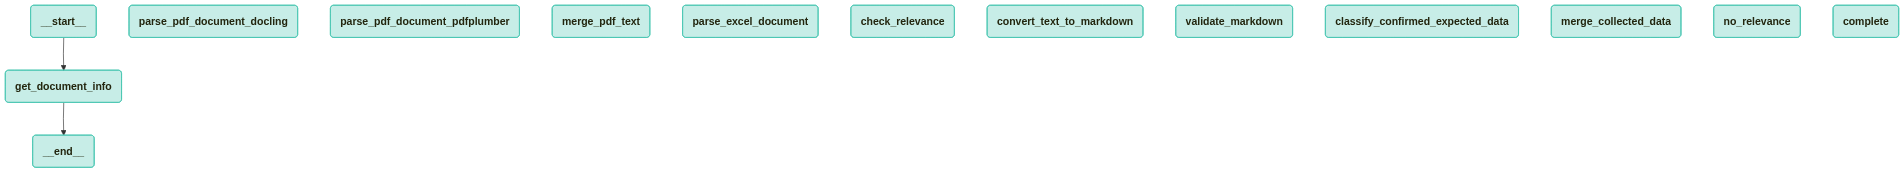

In [42]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(graph, xray=True)

# Graph 실행

In [43]:
# graph 실행

# text 추출 태스트

# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/라이나_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(2차)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(액티브)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/신한라이프(퇴직)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/카디프_251127.pdf"
_document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/하나생명(액티브)_251127.pdf"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/iM라이프_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/ABL_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/DB_250826.xlsx"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/KB라이프_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_variable_annuity/KB라이프(액티브)_250826.xls"
# _document_file_path = "/Users/bhkim/20_code_test/documents/sample_overseas_settlement/LS.pdf"

_password = None
# _password = '345678'
result = graph.invoke({"file_path": _document_file_path, "password": _password})

# print(result)
result_markdown_text = result["markdown_text"]



   file_path : /Users/bhkim/20_code_test/documents/sample_variable_annuity/하나생명(액티브)_251127.pdf
   file_name : 하나생명(액티브)_251127.pdf
   file_ext : .pdf
****************routing_parser****************
   .pdf
pdfplumber


Stage preprocess failed for run 1, pages [0]: [json.exception.type_error.302] type must be number, but is array
Stage preprocess failed for run 1, pages [1]: [json.exception.type_error.302] type must be number, but is array
Stage preprocess failed for run 1, pages [2]: [json.exception.type_error.302] type must be number, but is array
Stage preprocess failed for run 1, pages [3]: [json.exception.type_error.302] type must be number, but is array


RuntimeError: PDF 텍스트 추출 실패: Conversion failed for: 하나생명(액티브)_251127.pdf with status: ConversionStatus.FAILURE. Errors: Page 1: [json.exception.type_error.302] type must be number, but is array; Page 2: [json.exception.type_error.302] type must be number, but is array; Page 3: [json.exception.type_error.302] type must be number, but is array; Page 4: [json.exception.type_error.302] type must be number, but is array

# Markdown 정리 결과

In [ ]:
from IPython.display import Markdown, display

print(f"file_name : {result['file_name']}")
# print(result_markdown_text)
display(Markdown(result_markdown_text))

# 확정분과 청구분 구분 정리

In [ ]:
display(Markdown(result["confirmed_expected_data"]))

In [ ]:
# display(Markdown(result["markdown_text"]))

# 확정분 수집 결과

In [ ]:
# display(Markdown(result["confirmed_data"]))

# 청구분 수집 결과

In [ ]:
# display(Markdown(result["expected_data"]))